# 第9回講義 演習

本演習では，ローカルLLMに対してSupervised Fine-Tuning (SFT)を行い，特定のタスクに対する性能が向上することを確認します．

<figure align="center">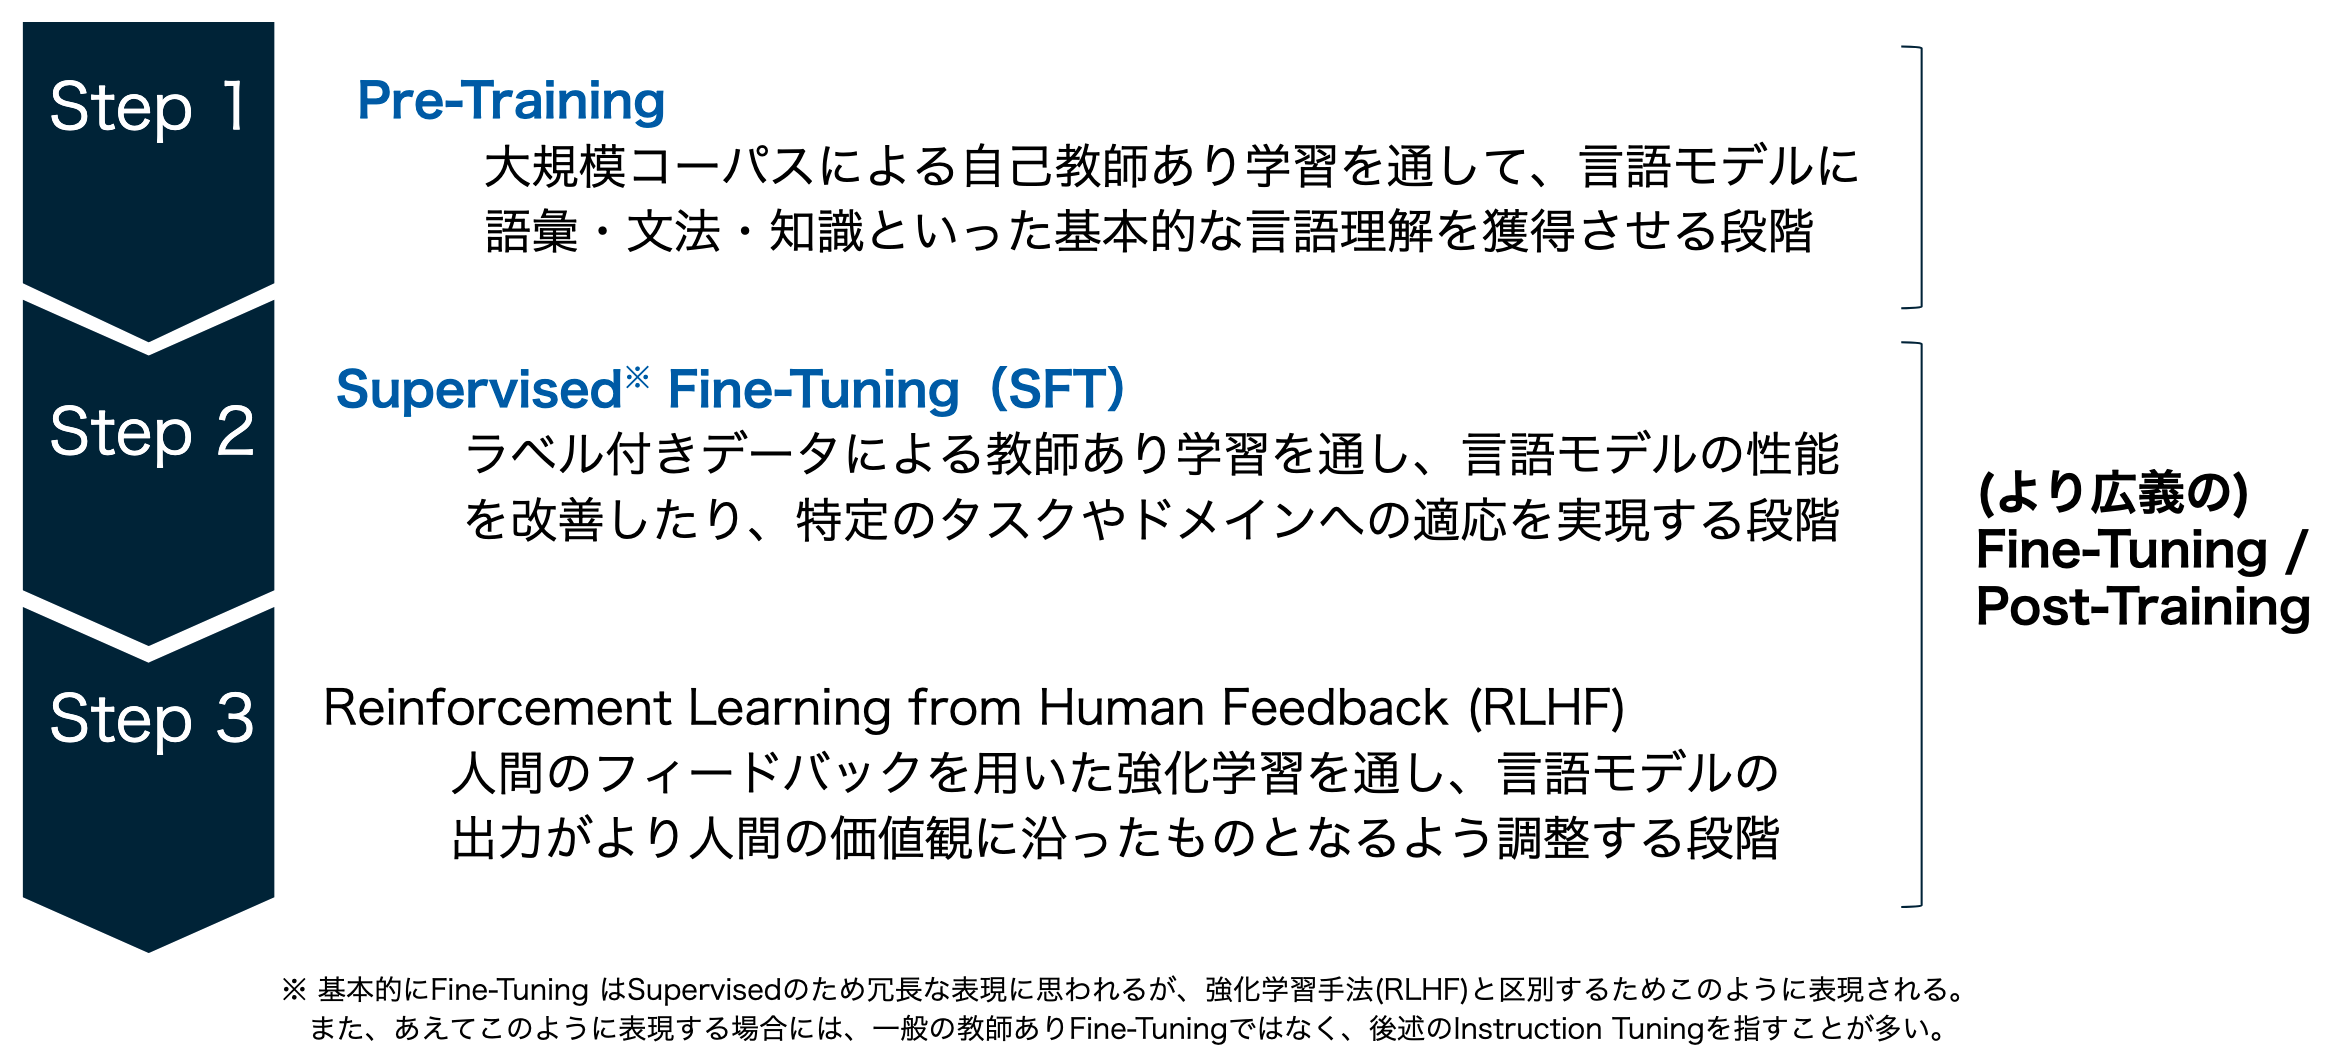<figcaption></figcaption></figure>

SFT (Supervised Fine-Tuning)は，LLMを特定のタスクやドメインに適応させるための事後学習の一種です．具体的には，教師あり学習を用いて，モデルが特定の入力に対して正しい出力を生成できるように調整します．

通常，事前学習済みのモデルに対して追加のデータセットを用いてSFTが行われます．このプロセスでは，モデルが特定のタスクやドメインに関連するデータセットから学習し，固有の知識やパターンを獲得します．


SFTは，LLMの学習フローにおいて，Reinforcement Learning from Human Feedback (RLHF)などの前段階として行われるのが一般的ですが，目的によってはそれ単体で十分な性能が得られる場合も多くあります．

今回は質問応答，中でも選択式で様々な分野における言語理解能力をテストするベンチマークである[MMLU](https://huggingface.co/datasets/cais/mmlu) (Massive Multitask Language Understanding)を取り扱います．

- モデル出力が選択肢のうちの一つとなることを想定できるため，評価が容易になります．

## 目次

1. [モデルの読み込み](#scrollTo=r2v_X2fA0Df5)

2. [データの準備](#scrollTo=vITh0KVJ10qX)

  2.1. [データの確認](#scrollTo=L59WPp5rBbYr)

  2.2. [データの成形](#scrollTo=rTALTVFUe6W8)

  2.3. [トークン系列長分布の確認](#scrollTo=GO9XiWuh0HHB)

3. [学習](#scrollTo=idAEIeSQ3xdS)

  3.1. [SFT用モデルの準備](#scrollTo=JUsYWTyMc1us)

  3.2. [実行](#scrollTo=tz08vhZIg6BH)

  3.3. [モデルの保存](#scrollTo=3aZnsQzModjt)

4. [評価](#scrollTo=ekOmTR1hSNcr)

  4.1. [評価関数の実装](#scrollTo=1XhW-6Koq40s)

  4.2. [実行](#scrollTo=dgdKgOqLzzyL)

  4.3. [評価に関する注意](#scrollTo=wXyprIgPIO_G)

5. [参考文献](#scrollTo=gTfCia8K0uRI)

本演習では，LLM学習用のライブラリ<a href="https://github.com/unslothai/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115" alt="unsloth"></a>と[TRL](https://github.com/huggingface/trl) (Transformer Reinforcement Learning)を使用します．

- Unsloth：各種最適化により精度を損なうことなくSFTの省メモリと高速化を実現している，Hugging Faceの標準的な記法で利用可能なライブラリの一つ
- TRL：SFTや強化学習，[DPO](https://arxiv.org/abs/2305.18290) (Direct Preference Optimization)など様々な学習をサポートしているライブラリ

LLM学習の技術開発は発展途上であり，頻繁に新しい技術を取り入れたライブラリが登場します．高速化やメモリ効率化などにより多くのユーザーを獲得している新たなライブラリを定期的にチェックするようにしましょう．

In [ ]:
%%capture
# Colab notebookでは少し特殊なインストールをする必要がある．他の環境ではpip install unslothで入る
!pip install --no-deps bitsandbytes==0.45.5 accelerate==1.6.0 xformers==0.0.29.post3 peft==0.15.2 trl==0.15.2 triton==3.2.0 cut_cross_entropy==25.1.1 unsloth_zoo==2025.5.8
!pip install sentencepiece==0.2.0 protobuf==5.29.4 "datasets>=3.4.1" huggingface_hub==0.31.2 hf_transfer==0.1.9
!pip install --no-deps unsloth==2025.5.7

In [ ]:
import os, re
import random
import json
import torch
from unsloth import FastLanguageModel
from trl import SFTTrainer, SFTConfig
from transformers import TrainingArguments
from datasets import load_dataset, DatasetDict
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
from functools import partial

os.environ['UNSLOTH_RETURN_LOGITS'] = '1'

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


学習のログやモデルを保存するため，Google Driveをマウントします．

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# 保存先ディレクトリ指定．適宜書き換えてください．
WORK_DIR = Path("/content/drive/MyDrive/dlbasic_lecture09")
WORK_DIR.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


## 【課題】ローカルLLMのQLoRAによるSFT

## 1.モデルの読み込み

Unslothが用意したpre-trainedモデルから利用するものを指定しロードします．Tokenizerも一緒にロードされます．
- 他の利用可能なモデルは[こちら](https://huggingface.co/unsloth)などを参照

In [ ]:
MODEL_NAME = "unsloth/gemma-2-9b-bnb-4bit"
MAX_SEQ_LENGTH = 2048

base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True, # 名前に4bitとついていないモデルはFalse
    dtype=None, # Noneにしておけば自動で設定
)

==((====))==  Unsloth 2025.5.7: Fast Gemma2 patching. Transformers: 4.51.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/6.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

## 2.データの準備

[MMLU](https://huggingface.co/datasets/cais/mmlu)は，代数学や解剖学，天文学など，57の分野における選択式の問題を集めたベンチマークデータセットです．

ここではその中身を確認した後，SFTに適した形に成形していきます．

### 2.1. データの確認

まず，Hugging Face Hubからデータセットをロードします．

2つ目の引数で`abstract_algebra`, `anatomy`, `astronomy`, ...などロードする分野を指定できますが，今回は`all`ですべてを使用します．

<!--
データは学習用(train)、検証用(eval)、テスト用(test)の３つに分割するのが一般的である。検証用データは学習途中にlossなどの評価指標を計算し過学習などを確認するのに用いられ、テスト用データは学習後にモデルの性能を図るために用いられる。なお、検証用データはハイパーパラメータチューニングで用いられることもある。

データサイズが極めて小さい場合、検証用データを用意せず、学習用データで代用することもある。
-->

In [ ]:
dataset = load_dataset("cais/mmlu", "all")

README.md:   0%|          | 0.00/53.2k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/138k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/3.50M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/408k [00:00<?, ?B/s]

dev-00000-of-00001.parquet:   0%|          | 0.00/76.5k [00:00<?, ?B/s]

auxiliary_train-00000-of-00001.parquet:   0%|          | 0.00/47.5M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/14042 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1531 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/285 [00:00<?, ? examples/s]

Generating auxiliary_train split:   0%|          | 0/99842 [00:00<?, ? examples/s]

MMLUは評価用ベンチマークのため，訓練セットは存在しません．しかし，`test`セットには本演習の目的に十分なサンプル数が存在するため，これを訓練に用い，`validation`セットで評価を行なっていきます．
- [ARC](https://huggingface.co/datasets/allenai/ai2_arc), [MC_TEST](https://huggingface.co/datasets/sagnikrayc/mctest), [OpenBookQA](https://huggingface.co/datasets/allenai/openbookqa)など他の選択式ベンチマークデータセットから集められた`auxiliary_train`セットが存在しますが，今回は使用しません．

In [ ]:
dataset

DatasetDict({
    test: Dataset({
        features: ['question', 'subject', 'choices', 'answer'],
        num_rows: 14042
    })
    validation: Dataset({
        features: ['question', 'subject', 'choices', 'answer'],
        num_rows: 1531
    })
    dev: Dataset({
        features: ['question', 'subject', 'choices', 'answer'],
        num_rows: 285
    })
    auxiliary_train: Dataset({
        features: ['question', 'subject', 'choices', 'answer'],
        num_rows: 99842
    })
})

データの中身を確認します．セルを実行した後，出力右上の"Convert this dataframe to an interactive table"をクリックすることで見やすくなります．

In [ ]:
dataset["test"].to_pandas()

,question,subject,choices,answer
0,Find the degree for the given field extension ...,abstract_algebra,"[0, 4, 2, 6]",1
1,"Let p = (1, 2, 5, 4)(2, 3) in S_5 . Find the i...",abstract_algebra,"[8, 2, 24, 120]",2
2,Find all zeros in the indicated finite field o...,abstract_algebra,"[0, 1, 0,1, 0,4]",3
3,Statement 1 | A factor group of a non-Abelian ...,abstract_algebra,"[True, True, False, False, True, False, False,...",1
4,Find the product of the given polynomials in t...,abstract_algebra,"[2x^2 + 5, 6x^2 + 4x + 6, 0, x^2 + 1]",1
...,...,...,...,...
14037,What has been a central focus of religious tra...,world_religions,"[Peace and harmony, Power and influence, Truth...",0
14038,To whom did ordinary folk appeal during a dro...,world_religions,"[The Buddha, Laozi, The Queen Mother of the We...",2
14039,The theological term homoousios means which o...,world_religions,"[of a similar substance, of the same substance...",1
14040,"According to the Japanese origin myth, who giv...",world_religions,"[Es, Izanagi, Izanami, Kami]",1


### 2.2. データの成形

データの中身がわかったので，`question`, `choices`, `answer`を使用し，実際に学習で使用するテキストを成形します．

- `batched=True`で呼んでいる`formatting_prompts_func`には，`question`, `choices`, `answer`の各値がテキストのリストになったバッチ`examples`が入力されます．これを念頭において実装しましょう．

<!--
SFTするモデルがinstructデータの場合、そのひな型（プロンプト）に従うのが望ましい。baseモデルの場合はケースバイケースだが、ここでは実績のあるAlpacaプロンプトを採用する。

読み込んだtsvのデータをAlpacaプロンプトに沿った形式に代入することで学習しやすいデータに変換する。
-->

In [ ]:
prompt = """{}

### Choices:
{}

### Answer:
{}"""


def formatting_prompts_func(examples, train=True):
    # テキストのリスト
    questions = examples["question"]
    choice_lists = examples["choices"]
    answers = examples["answer"]

    texts = []
    for question, choices, answer in zip(questions, choice_lists, answers):
        # 評価であればanswerを追加しない
        if not train:
            answer = ""

        # テンプレートに代入してモデル入力を作成
        text = prompt.format(question, choices, answer) # WRITE ME

        # 訓練であれば最後にEOSトークンを追加
        if train:
            # tokenizerをグローバルスコープで使用していることに注意
            text += tokenizer.eos_token # WRITE ME

        texts.append(text)

    return {"text": texts}


# 成形処理の実行
train_dataset = dataset["test"].map(formatting_prompts_func, batched=True) # WRITE ME
test_dataset = dataset["validation"].map(
    partial(formatting_prompts_func, train=False),
    batched=True,
)

Map:   0%|          | 0/14042 [00:00<?, ? examples/s]

Map:   0%|          | 0/1531 [00:00<?, ? examples/s]

成形処理により，データセットに`text`が追加されました．

In [ ]:
train_dataset

Dataset({
    features: ['question', 'subject', 'choices', 'answer', 'text'],
    num_rows: 14042
})

成形後の訓練サンプルを1つ確認してみます．

In [ ]:
print(train_dataset["text"][0])

Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over Q.

### Choices:
['0', '4', '2', '6']

### Answer:
1<eos>


テストサンプルにはanswerとEOSが追加されていないことを確認します．

In [ ]:
print(test_dataset["text"][0])

The cyclic subgroup of Z_24 generated by 18 has order

### Choices:
['4', '8', '12', '6']

### Answer:



### 2.3. トークン系列長分布の確認

モデル入力のトークン系列長の分布を確認しておきます．

- 本演習では行いませんが，訓練時`SFTTrainer`に渡す`data_collator`関数を実装し，内部で適切にpadding / truncationなどを行うことで，より明示的で安全な訓練を行うことができます．

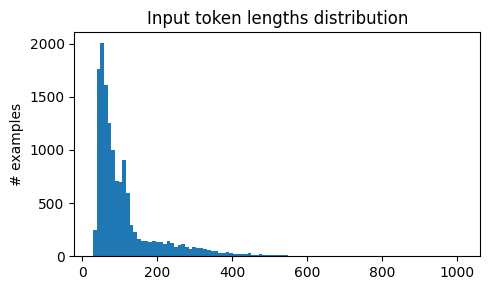

In [ ]:
lengths = [len(ids) for ids in tokenizer(train_dataset["text"])["input_ids"]]

fig, ax = plt.subplots(figsize=(5, 3), tight_layout=True)
ax.hist(lengths, bins=100)
ax.set_ylabel("# examples")
ax.set_title("Input token lengths distribution")
plt.show()

## 3.学習

モデルの学習には[QLoRA](https://arxiv.org/abs/2305.14314) (Quantized Low-Rank Adaptation)という，LoRAに量子化を追加した手法を用います．
- 4bit量子化されたモデルを直接読み込むことでメモリを大幅に節約し，GPU RAM 15GB程度のColab環境でも，8BクラスのLLMをfine-tuningすることが可能になります．
- 今回はunslothが用意したモデルを使用しますが，transformersのモデルを[bitsandbytes](https://github.com/bitsandbytes-foundation/bitsandbytes)ライブラリで量子化することなどもできます．

<!--
タスクを絞った場合、ELYZA-tasks-100やJapanese-MT-Benchといったベンチマークで優れたモデルが最適とは限らない。時間やリソースに余裕があれば複数のモデルを比較することが望ましい。

演習内ではunsloth/gemma-2-9b-bnb-4bitの結果を示す。
-->

**LoRA (Low-Rank Adaptation)**

<figure align="center">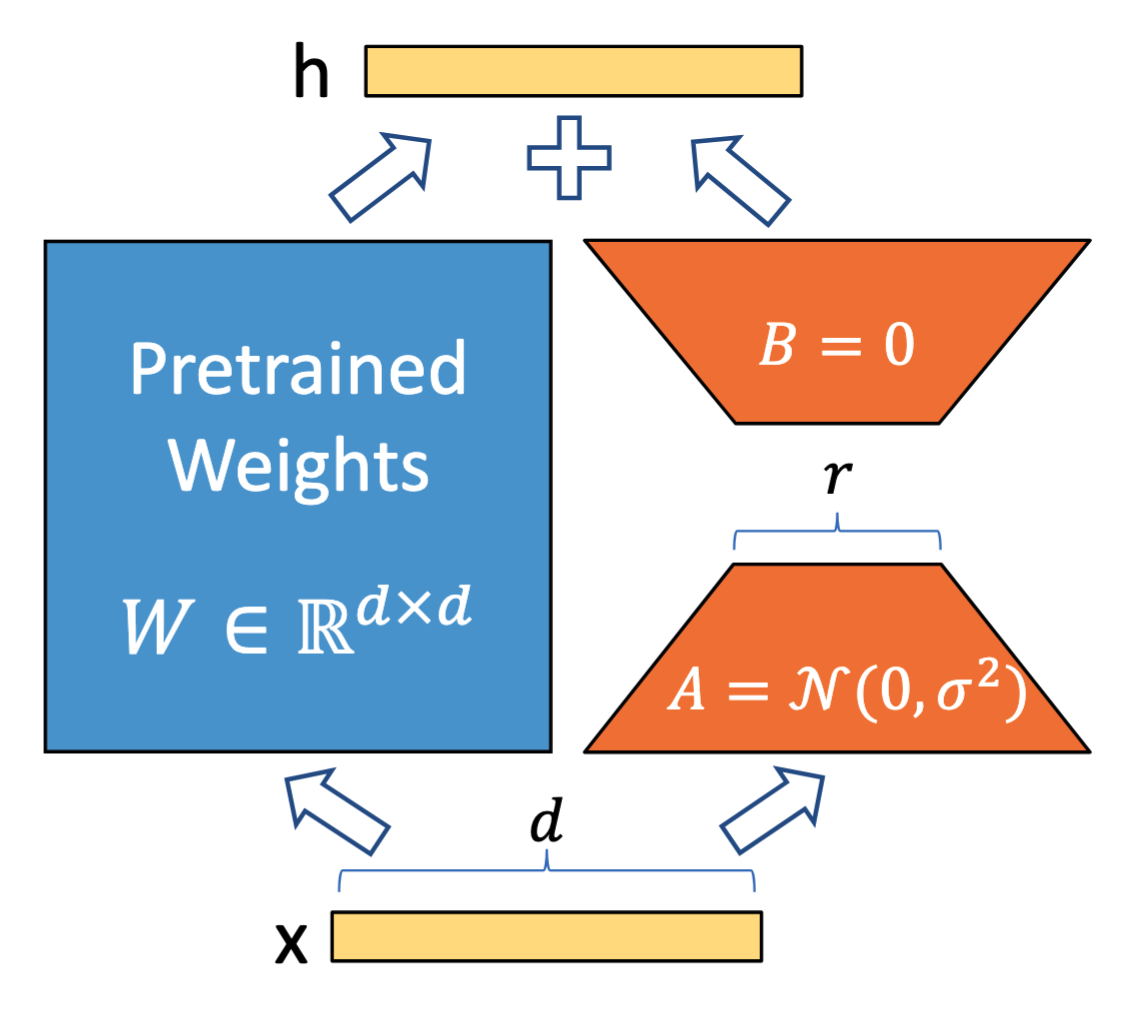<figcaption>Hu+ 2021</figcaption></figure>

LoRAは，大規模な深層モデルをfine-tuningする手法の一つです．具体的には，モデルの学習対象の層の**重み$W_0 \in \mathbb{R}^{d \times k}$はそのままに，それに足す差分$\Delta W \in \mathbb{R}^{d \times k}$を学習**します．

しかし，$\Delta W$もまた大きな行列なので，学習には大きなメモリを消費してしまいます．LoRAでは，**$\Delta W$をより小さな行列$B \in \mathbb{R}^{d \times r}$と$A \in \mathbb{R}^{r \times k}$の行列積で表現**する（ランクを下げる）ことで，これを解決します．

層の入力を$x$としたとき，学習後の出力$h$は以下のように書き表されることになります．このように分解されることで，$W_0$を固定したまま学習できることがわかります．

$$
h = W_0 x + \Delta W x = W_0 x + BA x
$$

### 3.1. SFT用モデルの準備

Unslothでは，モデルAPIの`get_peft_model`というメソッドを用いモデルをSFT用に変換します．

- PEFT (Parameter-Efficient Fine-Tuning)はLLMをfine-tuningする手法の総称で，LoRAはこれに含まれます．
  - 他のPEFT手法は[こちら](https://huggingface.co/docs/peft/en/conceptual_guides/adapter)などを参照

LoRAに関連するパラメータ（詳しくはPEFTの[LoraConfig](https://huggingface.co/docs/peft/package_reference/lora#peft.LoraConfig)を参照）

- `r`：ランク（$A$と$B$が持つ次元数）．小さいほどメモリが節約されるが性能が落ちる．
- `target_modules`：学習対象とする層（モジュール）のリスト
- `lora_alpha`：ランクを下げることにより変わった層出力をリスケールするハイパーパラメータ
- `lora_dropout`：LoRAアダプターのドロップアウト率

In [ ]:
# SFT用のモデルを用意．ここでLoRAの設定
model = FastLanguageModel.get_peft_model(
    base_model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)

Unsloth 2025.5.7 patched 42 layers with 42 QKV layers, 42 O layers and 42 MLP layers.


### 3.2. 実行

学習に関連するパラメータ（詳しくはTRLの[SFTConfig](https://huggingface.co/docs/trl/sft_trainer#trl.SFTConfig)を参照）

- `per_device_train_batch_size`：1GPUあたりのバッチサイズ
- `gradient_accumulation_steps`：勾配を累積するステップ数（メモリ使用量を変えずに実質的なバッチサイズを増加）
- `num_train_epochs`：エポック数
- `eval_strategy`：評価を行う間隔を指定する方法（`epoch`も指定可能）
- `eval_steps`：評価を行う間隔ステップ数（エポック数ではないことに注意）


In [ ]:
training_arguments = SFTConfig(
    dataset_text_field="text",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    warmup_steps=5,
    num_train_epochs=1,
    learning_rate=2e-5,
    eval_strategy="steps",
    eval_steps=50,
    logging_steps=1,
    optim="adamw_8bit",
    weight_decay=0.01,
    lr_scheduler_type="linear",
    seed=3407,
    output_dir=WORK_DIR / "outputs",
    report_to="tensorboard",
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    args=training_arguments,
)

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/14042 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/1531 [00:00<?, ? examples/s]

それでは学習を実行しましょう．
- 1エポックのみで指定していますが，4時間程度かかります．
- 使用中のGPU RAMなどは右上の「RAM / ディスク」からリソースパネルで確認できます．

In [ ]:
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 14,042 | Num Epochs = 1 | Total steps = 877
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 54,018,048/9,000,000,000 (0.60% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
50,1.906400,2.116404
100,1.417800,1.974552
150,1.283300,1.949962
200,1.713500,1.938154
250,1.572000,1.930764
300,1.766600,1.931719
350,1.533100,1.924639
400,1.679100,1.924444
450,1.372400,1.919810
500,1.357300,1.919096


Unsloth: Not an error, but Gemma2ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


TrainOutput(global_step=877, training_loss=1.538239776476487, metrics={'train_runtime': 17261.1664, 'train_samples_per_second': 0.814, 'train_steps_per_second': 0.051, 'total_flos': 1.4995056705080525e+17, 'train_loss': 1.538239776476487})

学習曲線の確認にはTensorboardを用います．

- 起動する際，`logdir`で指定したディレクトリ以下にあるすべての`tfevents`ファイルを再帰的に探して読み込みます．左のパネルから表示したい学習以外のチェックを外してください．
- SCALARSタブから学習曲線を確認できます．左のパネルにおいてSmoothingを0.0にすることで，実際の学習曲線を見やすくできます．

In [ ]:
%load_ext tensorboard
logdir = str(WORK_DIR / "outputs")
%tensorboard --logdir=$logdir

### 3.3. モデルの保存

モデルの保存には，LoRAアダプターのみを保存する方法と，アダプターをマージしてモデル全体を保存する方法の2つがあります．

ここでは前者を実装しています．

- モデル全体を保存する方法は[save_pretrained_merged](https://docs.unsloth.ai/basics/running-and-saving-models/saving-to-vllm)を参照

In [ ]:
# LoRAアダプタのみの保存
model.save_pretrained(WORK_DIR / "lora_model")
tokenizer.save_pretrained(WORK_DIR / "lora_model")

('/content/drive/MyDrive/dlbasic_lecture09/lora_model/tokenizer_config.json',
 '/content/drive/MyDrive/dlbasic_lecture09/lora_model/special_tokens_map.json',
 '/content/drive/MyDrive/dlbasic_lecture09/lora_model/tokenizer.model',
 '/content/drive/MyDrive/dlbasic_lecture09/lora_model/added_tokens.json',
 '/content/drive/MyDrive/dlbasic_lecture09/lora_model/tokenizer.json')

## 4.評価

LLMの評価には，大きく2つのアプローチが存在します．

1. 自動評価：正解データと自動で評価するための関数を用意して評価
2. 手動評価：出力を人間が評価

今回は選択式の質問応答のため，関数を容易して自動で評価することができます．

- より複雑な文章生成タスクの場合でも，モデル出力をGPT4などに自動で評価させる枠組みも存在します．

<!--
大喜利の場合、自動で評価するための関数を用意することが困難なため人間が評価する。

どちらのアプローチをとるにせよ、以下のことを意識して評価項目を設計することをお勧めする。

### <u>成功することが大事か、失敗しないことが大事かをはっきりさせる</u>
出力がテキストの場合、成功と失敗にはグラデーションがある。失敗しても構わないが一定の確率で素晴らしい出力をするモデルが求められることもあれば、素晴らしい出力を出すことが少なくてもとにかく大失敗をしないモデルが求められることもある。

このことを意識して評価軸を設計しておくと、サービスへの実装ハードルが下がる。

### <u>最初から強化学習を前提に評価軸を設計する</u>

SFTで得られたモデルをそのままサービスとして実装できるとは限らず、強化学習によって性能を高めることを前提とした方がよい。その際、評価結果に過剰な偏りがでないように評価軸を設計する。また、人手による評価の場合は評価者が簡単に判断できる評価軸になるよう配慮する。

なお、unsloth+TRLではDPOが可能である(DPOは厳密には強化学習ではないがここでは強化学習と同列に扱う)。
-->

### 4.1. 評価関数の実装

評価関数にもある程度の任意性がありますが，ここでは最もシンプルに，**最初に出力されたEOSトークンの直前のトークンが正解の選択肢にマッチしているかどうか**で評価を行います．

In [ ]:
def evaluate(dataset, model, tokenizer):
    # モデルを評価モードにする
    model = FastLanguageModel.for_inference(model)

    accuracy = 0
    for example in tqdm(dataset):
        input_ids = tokenizer(example["text"], return_tensors="pt").to("cuda") # WRITE ME
        output_ids = model.generate(**input_ids, max_new_tokens=8, use_cache=True)
        output = tokenizer.decode(output_ids[0]) # WRITE ME

        eos_loc = output.find(tokenizer.eos_token)
        # EOSを出力していなければ間違いとする
        if eos_loc == -1:
            continue

        prediction = output[eos_loc - 1]
        # EOSの直前が数字でなければ必ず間違い
        if not prediction.isdigit():
            continue

        accuracy += int(prediction) == example["answer"]

    return accuracy / len(dataset)

### 4.2. 実行

まず，SFTを行っていない事前学習済みモデルを評価します．

In [ ]:
torch.cuda.empty_cache()

base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
    dtype=None,
)

test_acc = evaluate(test_dataset, base_model, tokenizer)
print(f"Base model test accuracy: {test_acc:.2f}")

  0%|          | 0/1531 [00:00<?, ?it/s]

Base model test accuracy: 0.00


次に，SFTを行い保存したモデルをロードし，評価します．

In [ ]:
torch.cuda.empty_cache()

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=str(WORK_DIR / "lora_model"), # 保存したディレクトリを指定
    max_seq_length=MAX_SEQ_LENGTH,
)

test_acc = evaluate(test_dataset, model, tokenizer)
print(f"SFT model test accuracy: {test_acc:.2f}")

==((====))==  Unsloth 2025.5.7: Fast Gemma2 patching. Transformers: 4.51.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 7.5. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth 2025.5.7 patched 42 layers with 42 QKV layers, 42 O layers and 42 MLP layers.


  0%|          | 0/1531 [00:00<?, ?it/s]

SFT model test accuracy: 0.69


SFTによりMMLUに対する性能が上昇したことを確認できました．

### 4.3. 評価に関する注意

SFTをする前のモデルの出力を確認すると，選択肢の番号ではなく選択肢そのものを回答していたり，評価において設定した`max_new_tokens=8`ではEOSの出力に至らなかったり（説明を続けようとしている）と，設定した評価関数ではあまり妥当に評価できていないことがわかります．

- ただし，評価関数が想定する形式での出力をするようになったという意味では，モデルの学習が進んだと言えます．

実際の研究では，様々なケースを考慮した評価関数を作成する必要があります．ご自身で試してみてください．

In [ ]:
SAMPLE_ID = 0

input_ids = tokenizer(test_dataset[SAMPLE_ID]["text"], return_tensors="pt").to("cuda")
output_ids = base_model.generate(**input_ids, max_new_tokens=8, use_cache=True)
output = tokenizer.decode(output_ids[0])
print(output)

<bos>The cyclic subgroup of Z_24 generated by 18 has order

### Choices:
['4', '8', '12', '6']

### Answer:
['4']

The cyclic subgroup of


## 5.参考文献
[1] Unsloth Jupyter Notebook [Gemma3_(4B).ipynb](https://colab.research.google.com/drive/1vIrqH5uYDQwsJ4-OO3DErvuv4pBgVwk4)

[2] [TRL documentation](https://huggingface.co/docs/trl/index)

[3] Dettmers, Tim, Artidoro Pagnoni, Ari Holtzman, and Luke Zettlemoyer. 2023. “QLoRA: Efficient Finetuning of Quantized LLMs.” arXiv [Cs.LG]. arXiv. http://arxiv.org/abs/2305.14314.